In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import scipy.stats as st
import src.eye_movement_preprocessing as emp

In [3]:
def get_uniform_cdf(first_trial_start, last_trial_start, first_trial_end, last_trial_end, scale):
    #first_trial_start = min(preprocessed_trial_data['startTime_to_startTime_to_flashOnTime_aligned'].values)
    #last_trial_start = max(preprocessed_trial_data['startTime_to_startTime_to_flashOnTime_aligned'].values)
    #first_trial_end = min(preprocessed_trial_data['endTime_to_startTime_to_flashOnTime_aligned'].values)
    #last_trial_end = max(preprocessed_trial_data['endTime_to_startTime_to_flashOnTime_aligned'].values)
    uniform_dist = []
    for val in scale:
        if val < first_trial_start:
            uniform_dist.append(0.00001)
        elif val >= first_trial_start and val < last_trial_start:
            uniform_dist.append((val - first_trial_start) / (last_trial_start - first_trial_start))
        elif val >= last_trial_start and val < first_trial_end:
            uniform_dist.append(1)
        elif val >= first_trial_end and val < last_trial_end:
            uniform_dist.append(- 1 * ((val - last_trial_end) / (last_trial_end - first_trial_end)))
        elif val >= last_trial_end:
            uniform_dist.append(0.00001)
        else:
            raise ValueError(f'{val} is a very weird value. {first_trial_start, last_trial_start, first_trial_end, last_trial_end}')
    return np.array(uniform_dist)


def get_relevant_blocks(original_block_list, skipped_blocks, reloaded_blocks):
                
    if type(skipped_blocks) == str:
        drop_blocks = [int(x) for x in skipped_blocks.split(',')]
        include_blocks = [x for x in original_block_list if x not in drop_blocks]
    elif np.isnan(skipped_blocks):
        include_blocks = [x for x in original_block_list]
    
    add_blocks = []
    
    if type(reloaded_blocks) == str:
        add_blocks = [int(x) for x in reloaded_blocks.split(',')]
    elif np.isnan(reloaded_blocks):
        pass
    elif type(reloaded_blocks) == np.float64:
        add_blocks = [reloaded_blocks]
    else:
        print(type(reloaded_blocks))
    for b in add_blocks:
        include_blocks.append(b)
        
    include_blocks.sort()
    
    # replace double blocks with nans
    no_change = np.where(np.diff(include_blocks) == 0)[0]
    if len(no_change)>0:
        for n in no_change:
            include_blocks[n] = np.nan
    
    return include_blocks

In [4]:
inside_marker = ['apriltag_v3:tag36h11:1','apriltag_v3:tag36h11:2','apriltag_v3:tag36h11:3']
outside_marker = ['apriltag_v3:tag36h11:10','apriltag_v3:tag36h11:20','apriltag_v3:tag36h11:30','apriltag_v3:tag36h11:40']

data_path = '../../../data/inlab/'
pix2deg_output_path = f'{data_path}target/preprocessed/px2deg_target.csv' # here we put the data path where we want to save the pixel to dva transformation
jatos_data_path = f'{data_path}target/preprocessed/clean_remote_data_target.csv'

jatos_data = pd.read_csv(jatos_data_path)
jatos_data = jatos_data.groupby(['participant_id', 'session_number']).mean(numeric_only=True)[['windowWidth', 'windowHeight']].reset_index(drop = False)

meta_data = pd.read_csv(f'{data_path}combined_meta/gaze_meta_info.csv')

screen_data = pd.read_csv(pix2deg_output_path)

light_df = pd.read_csv(f'{data_path}target/preprocessed/light_diode_blocks.csv') 

participants = ['P02', 'P03', 'P04', 'P05', 'P06', 'P07', 'P08', 'P09', 'P10', 'P11', 'P12', 'P13', 'P14', 'P15', 'P16', 'P17', 'P18', 'P19', 'P20', 'P21']
sessions = ['A1', 'A2']

In [5]:
regular_blocks = np.arange(1, 11)

meta_path = f'../../../data/target/combined_meta'

## THINK: the plots below are detected marker onset times, I want the time point when the last marker appears first to be by reference point. Filter this data point and check with recordings if matches.

In [6]:
confidence_level = 0.75
original_block_list = np.arange(1, 11)

calibration = pd.read_csv(f'{data_path}target/raw/calibration.csv')
for p in participants:
    for s in sessions:
        p_meta = meta_data[meta_data.participant == p]
        s_meta = p_meta[p_meta.session == s]
        
        saccades = pd.DataFrame()
        block_len = 0
        print(p, ' ' ,s)
        data_path_load = f'{data_path}target/raw/{p}/{s}'
    
        calib = calibration[calibration['participant_id'] == int(p[1:])]
        calib = calib[calib['session_number'] == int(s[1])]
        
        n_components = len(os.listdir(f'{data_path_load}/study-result_{p[1:]}_{s}'))

        for folder in ['surfaces', 'surfaces2']:
            if len(s_meta) == 2:
                if folder == 'surfaces':
                    r_meta = s_meta[s_meta.recording == 1]
                if folder == 'surfaces2':
                    r_meta = s_meta[s_meta.recording == 2]
            else:
                r_meta = s_meta
            
            split_data = r_meta.eyetracker_split.values[0]
            if r_meta.missing_blocks_not_in_et.values[0]:
                missing_blocks = np.nan
            else:
                missing_blocks = r_meta.missing_blocks.values[0]
            include_blocks_all = get_relevant_blocks(original_block_list, missing_blocks, r_meta.reloaded_blocks.values[0])
            
            if not np.isnan(split_data):
                if folder == "surfaces":
                    include_blocks = include_blocks_all[:int(split_data)]
                else:
                    include_blocks = include_blocks_all[int(split_data):]
            else:
                include_blocks = include_blocks_all
            try:
                gaze_data = pd.read_csv(f'{data_path_load}/{folder}/gaze_positions_on_surface_Phone.csv')
                marker_data = pd.read_csv(f'{data_path_load}/{folder}/marker_detections.csv')
                
                scaled_x, scaled_y = emp.scale_gaze_position(gaze_data, calib)
                gaze_data.loc[:, 'x_scaled'] = scaled_x
                gaze_data.loc[:, 'y_scaled'] = scaled_y
    
                gaze_data.loc[gaze_data.confidence < confidence_level, 'x_scaled'] = np.nan
                gaze_data.loc[gaze_data.confidence < confidence_level, 'y_scaled'] = np.nan
                
    
                block_id, gaze_time, world_time = emp.align_gaze_data_to_block_onset(gaze_data, 
                                                                                     marker_data, 
                                                                                     inside_marker, 
                                                                                     data_path_load,
                                                                                     include_blocks)
                gaze_data.loc[:, 'block_id'] = block_id
                gaze_data.loc[:, 'gaze_timestamp_block'] = gaze_time
                gaze_data.loc[:, 'world_timestamp_block'] = world_time


                trial_data = pd.read_csv(f'{data_path_load}/trial_events_jatos.csv')
                trial_id, gaze_time, world_time = emp.align_gaze_data_to_trial_onset(gaze_data,
                                                                                     trial_data)

                gaze_data.loc[:, 'trial_id'] = trial_id
                gaze_data.loc[:, 'gaze_timestamp_trial'] = gaze_time
                gaze_data.loc[:, 'world_timestamp_trial'] = world_time
                gaze_data.loc[:, 'gaze_timestamp_remodnav'] = gaze_data.loc[:, 'gaze_timestamp'] - gaze_data.loc[:, 'gaze_timestamp'][0]

                # for tid in np.unique(gaze_data.trial_id):
                #     if not np.isnan(tid):
                #         plt.scatter(gaze_data[gaze_data.trial_id == tid].x_scaled, gaze_data[gaze_data.trial_id == tid].y_scaled)
                #         plt.xlim([0,800])
                #         plt.ylim([0,600])
                #         if tid % 10 == 0:
                #             plt.show()

                gaze_data.to_csv(f'{data_path_load}/{folder}/normalized_position_with_blocks.csv', index = False)
    
            except FileNotFoundError as e:
                if not folder == 'surfaces2':
                    print(e)
                pass

P02   A1
P02   A2
P03   A1
P03   A2
P04   A1
P04   A2
P05   A1
P05   A2
P06   A1
P06   A2
P07   A1
P07   A2
P08   A1
P08   A2
P09   A1
P09   A2
P10   A1
P10   A2
P11   A1
P11   A2
P12   A1
P12   A2
P13   A1
P13   A2
P14   A1
P14   A2
P15   A1
P15   A2
P16   A1
P16   A2
P17   A1
P17   A2
P18   A1
P18   A2
P19   A1
P19   A2
P20   A1
P20   A2
P21   A1
P21   A2


In [7]:
## Saccades

In [8]:
all_saccades = pd.read_csv('../../../results/inlab/all_saccades.csv')
target_saccades = all_saccades[all_saccades.condition == 'A'].reset_index(drop=True)
target_saccades

,onset,duration,label,start_x,start_y,end_x,end_y,amp,peak_vel,med_vel,...,participant,condition,session,block,trial_n,trial_on_time,flash_shown,jump_shown,event_time,relative_eye_movement_time
0,0.307,0.032,SACC,317.68072,413.42384,438.60737,314.95505,3.344,247.854,92.062,...,2,A,1,1.0,1.0,0.306623,1.0,0.0,0.141659,0.164964
1,0.533,0.032,ISAC,411.44345,344.14289,412.96341,283.81008,1.294,132.671,30.628,...,2,A,1,1.0,1.0,0.532556,1.0,0.0,0.141659,0.390897
2,0.597,0.048,SACC,406.54619,274.49574,501.82162,229.57000,2.259,187.847,29.944,...,2,A,1,1.0,1.0,0.597108,1.0,0.0,0.141659,0.455449
3,0.863,0.040,SACC,514.62905,263.85243,616.19735,249.28519,2.200,150.418,53.396,...,2,A,1,1.0,1.0,0.871455,1.0,0.0,0.141659,0.729796
4,0.290,0.048,SACC,409.12432,229.05094,511.50842,216.03312,2.213,154.304,29.605,...,2,A,1,1.0,2.0,0.290484,1.0,0.0,0.591499,-0.301015
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
296,0.387,0.024,SACC,375.94594,284.03307,377.14544,310.05469,0.559,61.392,11.615,...,2,A,1,2.0,123.0,0.395387,1.0,0.0,0.504872,-0.109485
297,0.912,0.040,SACC,547.08830,305.74793,557.71199,280.37231,0.590,108.611,20.279,...,2,A,1,2.0,123.0,0.919879,1.0,0.0,0.504872,0.415007
298,1.364,0.065,SACC,619.80097,298.32943,277.22766,52.27220,9.045,377.681,117.946,...,2,A,1,2.0,123.0,1.395956,1.0,0.0,0.504872,0.891084
299,0.008,0.032,SACC,310.53329,228.09408,345.63416,292.62727,1.575,127.391,56.424,...,2,A,1,2.0,124.0,0.008069,1.0,0.0,0.225466,-0.217397


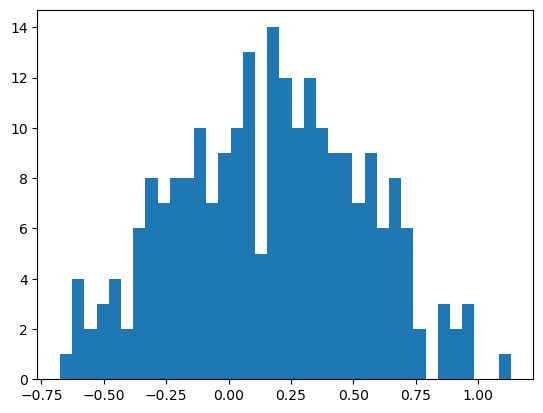

In [9]:
inhib_data = target_saccades[((target_saccades.flash_shown == 1) | (target_saccades.jump_shown == 1))]
inhib_data.loc[inhib_data.relative_eye_movement_time < -1, 'relative_eye_movement_time'] = np.nan
plt.hist(inhib_data.relative_eye_movement_time, 
         bins = len(np.arange(min(inhib_data.relative_eye_movement_time),
                              max(inhib_data.relative_eye_movement_time), 
                              0.05)));

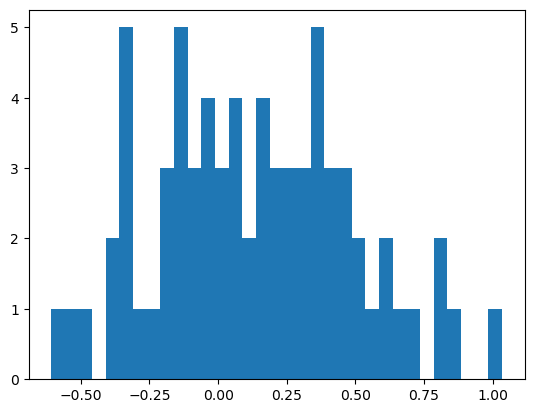

In [10]:
non_inhib_data = target_saccades[((target_saccades.flash_shown == 0) & (target_saccades.jump_shown == 0))]
plt.hist(non_inhib_data.relative_eye_movement_time, 
         bins = len(np.arange(min(non_inhib_data.relative_eye_movement_time),
                              max(non_inhib_data.relative_eye_movement_time), 
                              0.05)));